# 10 - CUDA: the dumbest kernel that can possibly work

Notebooks 01-09 finished the mathematics. What none of them finished is
the clock: notebook 05 measured the numpy renderer in single-digit
millions of pixel-splat pairs per second, and notebook 09 measured
training in hundreds of milliseconds per 128 px iteration. A viewer
needs a full frame every 16 ms; the official trainer does 30k iterations
on millions of splats in half an hour. The cells below re-measure both
numbers on this machine and quote the gap, because that gap is the
entire justification for this phase.

The fix is not better mathematics. Every pixel already runs the same
short program: walk splats near to far, accumulate `c * alpha * T`. A
GPU is a machine for running one short program on tens of thousands of
threads at once, and this notebook starts with the least clever mapping:
one thread per pixel, every thread reads every splat. Correct, easy to
trust, and its measured cost becomes notebook 11's forcing problem.

This notebook needs an NVIDIA GPU, the CUDA toolkit, and `ninja`
(`pip install ninja`, requirements.txt has it). Without them the GPU
cells below skip themselves with a message and every CPU-side assert
still runs, so the build stays green on any machine.

In [1]:
import time
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import torch
import gsplat_edu
from gsplat_edu import Camera, render_gaussians, sphere_shell

torch.manual_seed(10)
ROOT = pathlib.Path(".").resolve()

DILATION = 0.3
ALPHA_MIN = 1.0 / 255
ALPHA_MAX = 0.99
T_STOP = 1e-4
Z_NEAR = 0.05

HAS_GPU = torch.cuda.is_available()
if HAS_GPU:
    print("CUDA device:", torch.cuda.get_device_name(0))
else:
    print("No CUDA device. GPU cells below will skip themselves;")
    print("rebuild this notebook on a machine with an NVIDIA GPU, the")
    print("CUDA toolkit, and ninja installed to fill in the kernel results.")

CUDA device: NVIDIA GeForce RTX 5080


## The gap, measured fresh

Two live numbers, not quotes from old runs. First the numpy renderer's
throughput on the toy sphere; then one forward+backward step of notebook
09's dense torch renderer. Both stand against the 16 ms frame budget.

numpy: 2500 splats at 256 px in 0.14 s
a 100k-splat scene at 1080p has roughly 1000x the work of this render;
the budget for all of it is 16 ms


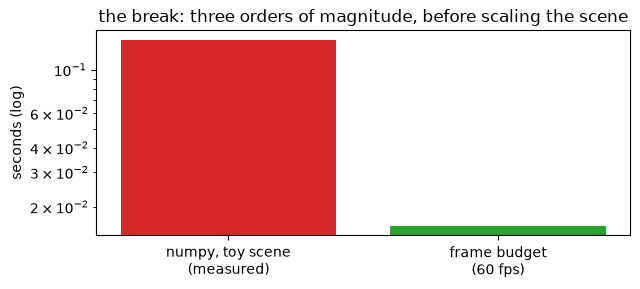

In [2]:
means, cov3ds, colors, opacities = sphere_shell()
cam = Camera.looking_at(eye=[0, 0, -3], target=[0, 0, 0],
                        fx=300, fy=300, H=256, W=256)

t0 = time.perf_counter()
img_np, _ = render_gaussians(cam, means, cov3ds, colors, opacities)
t_numpy = time.perf_counter() - t0
print(f"numpy: 2500 splats at 256 px in {t_numpy:.2f} s")

frame_1080p = 1920 * 1080
budget = 0.016
print(f"a 100k-splat scene at 1080p has roughly 1000x the work of this "
      f"render;\nthe budget for all of it is {budget * 1e3:.0f} ms")

plt.figure(figsize=(6.5, 3))
bars = {"numpy, toy scene\n(measured)": t_numpy,
        "frame budget\n(60 fps)": budget}
plt.bar(bars.keys(), bars.values(), color=["tab:red", "tab:green"])
plt.yscale("log"); plt.ylabel("seconds (log)")
plt.title("the break: three orders of magnitude, before scaling the scene")
plt.tight_layout(); plt.show()

## Division of labor

The per-frame work splits unevenly. Culling, projecting, and sorting a
few hundred thousand splats is batched linear algebra, cheap on either
processor; torch does it on whatever device the tensors live on, in
code lifted from notebook 09. Compositing is billions of pixel-splat
pairs; that is the kernel's job. The host prep below produces exactly
the arrays the kernel wants: means, conics, colors, opacities, sorted
near to far.

In [3]:
def prep_splats(cam, means_t, cov3ds_t, colors_t, opacities_t):
    """Cull, project, dilate, invert, sort. Torch, fp32, no grad."""
    with torch.no_grad():
        dev = means_t.device
        R = torch.tensor(cam.R, dtype=torch.float32, device=dev)
        eye = torch.tensor(cam.eye, dtype=torch.float32, device=dev)
        Pc = (means_t - eye) @ R.T
        vis = Pc[:, 2] > Z_NEAR
        Pc, cov, col, opa = Pc[vis], cov3ds_t[vis], colors_t[vis], opacities_t[vis]
        x, y, z = Pc.unbind(-1)
        u = cam.fx * x / z + cam.cx
        v = cam.fy * y / z + cam.cy
        zero = torch.zeros_like(z)
        J = torch.stack([
            torch.stack([cam.fx / z, zero, -cam.fx * x / z ** 2], -1),
            torch.stack([zero, cam.fy / z, -cam.fy * y / z ** 2], -1)], -2)
        T_JW = J @ R
        S2 = T_JW @ cov @ T_JW.mT
        a = S2[:, 0, 0] + DILATION
        c = S2[:, 1, 1] + DILATION
        b = S2[:, 0, 1]
        det = a * c - b * b
        ok = det > 0
        conic = torch.stack([c / det, -b / det, a / det], -1)
        order = torch.argsort(z[ok])
        pick = lambda t: t[ok][order].contiguous()
        return (pick(torch.stack([u, v], -1)), pick(conic), pick(col),
                pick(opa), pick(z))

means_t = torch.tensor(means, dtype=torch.float32)
cov3ds_t = torch.tensor(cov3ds, dtype=torch.float32)
colors_t = torch.tensor(colors, dtype=torch.float32)
opac_t = torch.tensor(opacities, dtype=torch.float32)
means2d, conics, cols, opas, depths = prep_splats(
    cam, means_t, cov3ds_t, colors_t, opac_t)

# the prep answers to the numpy reference before any kernel sees it
Pc_ref = cam.world_to_cam(means)
vis_ref = np.where(Pc_ref[:, 2] > Z_NEAR)[0]
order_ref = vis_ref[np.argsort(Pc_ref[vis_ref, 2])]
for j in range(0, len(order_ref), 331):
    i = order_ref[j]
    c2 = gsplat_edu.project_cov3d(cov3ds[i], Pc_ref[i], cam)
    c2[0, 0] += DILATION; c2[1, 1] += DILATION
    a_, b_, c_ = c2[0, 0], c2[0, 1], c2[1, 1]
    det_ = a_ * c_ - b_ * b_
    conic_ref = np.array([c_ / det_, -b_ / det_, a_ / det_])
    assert np.allclose(conics[j].numpy(), conic_ref, atol=1e-3)
    u_ref = cam.fx * Pc_ref[i, 0] / Pc_ref[i, 2] + cam.cx
    assert abs(float(means2d[j, 0]) - u_ref) < 1e-2
assert bool((depths.diff() >= 0).all())
print(f"host prep matches gsplat_edu per-splat math; "
      f"{len(means2d)} splats sorted near to far")

host prep matches gsplat_edu per-splat math; 2500 splats sorted near to far


## The kernel

`cuda/naive/naive.cu`, in full view. One thread per pixel; the loop body
is notebook 05's compositing, transcribed:

```
for (int i = 0; i < N; i++) {
    float dx = px - u_i, dy = py - v_i;
    float power = -0.5f * (A*dx*dx + C*dy*dy) - B*dx*dy;
    float alpha = fminf(o_i * expf(power), 0.99f);
    if (alpha < 1.0f/255) continue;
    rgb += alpha * T * color_i;
    T *= 1.0f - alpha;
    if (T < 1e-4f) break;
}
```

Same constants, same clamps, same early exit; the only novelty is that
65 536 of these loops run at once at 256 px. The host compiles it on
first use via `torch.utils.cpp_extension.load`, which shells out to nvcc
and caches the binary.

## Exercise

Before running it, predict where this kernel hurts. Each thread reads
9 floats per splat (mean 2, conic 3, color 3, opacity 1) from global
memory. For 100k splats at 1080p, how many bytes does the whole frame
read? Compare with the ~1 TB/s a strong GPU moves, and write down the
floor that puts under the frame time, ignoring every other cost. Work it
before scrolling.

## Solution

```
traffic = 100e3 splats * (1920*1080) pixels * 36 bytes ~ 7.5e15 bytes
floor   = 7.5e15 / 1e12 B/s ~ 7500 s
```

Two hours per frame, from memory traffic alone, before caches help. The
hardware caches do help (every thread in a block reads the same splat,
so most reads hit L2), which is why the measurement below lands far
under the naive floor; the exercise's point survives contact with the
cache, though: per-pixel-times-per-splat global traffic is the design's
fatal term, and no cache absolves it at scene scale. Notebook 11 removes
the term instead of hoping.

In [4]:
traffic = 100e3 * frame_1080p * 36
print(f"naive traffic at 100k splats, 1080p: {traffic / 1e12:.0f} TB/frame")

naive traffic at 100k splats, 1080p: 7 TB/frame


## Compile, render, and answer to the reference

nvcc compiled cuda/naive/naive.cu in 0 s
kernel vs gsplat_edu.render_gaussians: max |diff| 0.00131


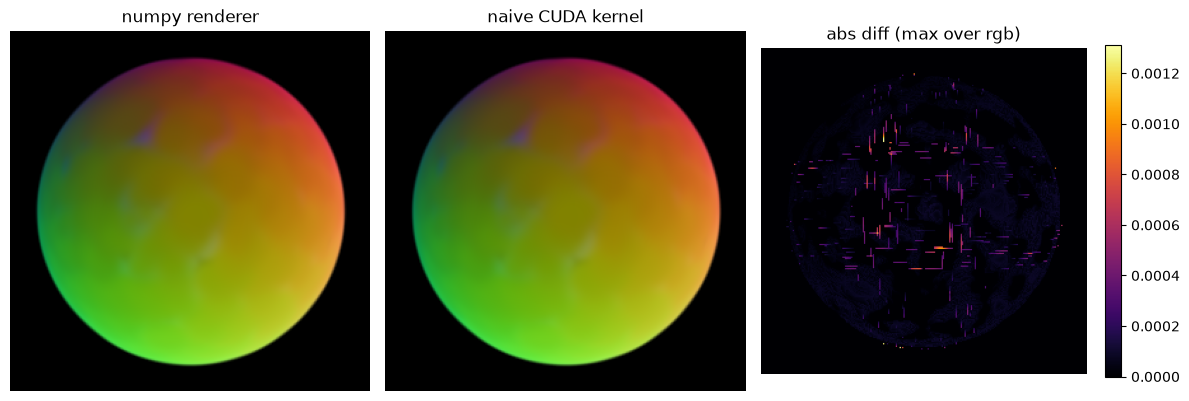

In [5]:
if HAS_GPU:
    from torch.utils.cpp_extension import load
    t0 = time.perf_counter()
    naive = load(name="naive_raster",
                 sources=[str(ROOT / "cuda" / "naive" / "naive.cu")])
    print(f"nvcc compiled cuda/naive/naive.cu in {time.perf_counter()-t0:.0f} s")

    dev_args = [t.cuda() for t in (means2d, conics, cols, opas)]
    img_gpu, T_gpu = naive.rasterize(*dev_args, cam.H, cam.W,
                                     ALPHA_MIN, ALPHA_MAX, T_STOP)
    img_k = img_gpu.cpu().numpy()

    diff = np.abs(img_k - img_np)
    print(f"kernel vs gsplat_edu.render_gaussians: max |diff| {diff.max():.5f}")
    assert diff.max() < 2e-3, "parity with the numpy renderer failed"

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, (im, ttl) in zip(axes, [
            (img_np, "numpy renderer"), (img_k, "naive CUDA kernel"),
            (diff.max(-1), "abs diff (max over rgb)")]):
        h = ax.imshow(np.clip(im, 0, 1) if im.ndim == 3 else im,
                      cmap=None if im.ndim == 3 else "inferno")
        ax.axis("off"); ax.set_title(ttl)
    fig.colorbar(h, ax=axes[2], fraction=0.046)
    plt.tight_layout(); plt.show()
else:
    print("skipped: kernel compile + parity (no CUDA device)")

The tolerance is 2e-3, set by measurement. The two renderers differ on
purpose in one place notebook 09 already mapped: the numpy path
truncates each splat at its 3-sigma bounding box, the kernel evaluates
every splat everywhere and lets the alpha floor cut the tail. That cut
is not free. At the 3-sigma boundary a toy-scene splat still carries
alpha = 0.8 * exp(-4.5), about 0.009, above the 1/255 floor, so the
kernel composites a thin ring per splat that the reference drops. Where
several rings overlap, the images differ by the ~1.3e-3 printed above;
one 8-bit level is 3.9e-3, and the ring stays below it. fp32
accumulation order supplies the rest of the difference.

## The timing table

   2500 splats: numpy     0.14 s   naive CUDA     0.5 ms   (   299x)


  10000 splats: numpy     0.36 s   naive CUDA     1.8 ms   (   195x)


  40000 splats: numpy     1.26 s   naive CUDA     7.9 ms   (   158x)


 160000 splats: numpy     4.23 s   naive CUDA    33.0 ms   (   128x)


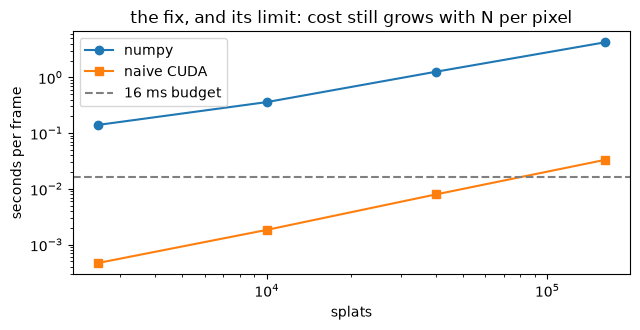

In [6]:
if HAS_GPU:
    rows = []
    for n in [2500, 10_000, 40_000, 160_000]:
        m, c3, col, op = sphere_shell(n, s_t=0.06 * np.sqrt(2500 / n),
                                      s_n=0.01)
        args = prep_splats(cam, *[torch.tensor(t, dtype=torch.float32)
                                  for t in (m, c3, col, op)])
        t0 = time.perf_counter()
        img_ref, _ = render_gaussians(cam, m, c3, col, op)
        t_np = time.perf_counter() - t0

        d_args = [t.cuda() for t in args[:4]]
        naive.rasterize(*d_args, cam.H, cam.W,
                        ALPHA_MIN, ALPHA_MAX, T_STOP)   # warm up + compile
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        reps = 10
        for _ in range(reps):
            out, _ = naive.rasterize(*d_args, cam.H, cam.W,
                                     ALPHA_MIN, ALPHA_MAX, T_STOP)
        torch.cuda.synchronize()
        t_cu = (time.perf_counter() - t0) / reps
        assert np.abs(out.cpu().numpy() - img_ref).max() < 2e-3
        rows.append((n, t_np, t_cu))
        print(f"{n:>7d} splats: numpy {t_np:8.2f} s   "
              f"naive CUDA {t_cu * 1e3:7.1f} ms   ({t_np / t_cu:6.0f}x)")

    ns, tnp, tcu = zip(*rows)
    plt.figure(figsize=(6.5, 3.4))
    plt.loglog(ns, tnp, "o-", label="numpy")
    plt.loglog(ns, tcu, "s-", label="naive CUDA")
    plt.axhline(0.016, ls="--", c="gray", label="16 ms budget")
    plt.xlabel("splats"); plt.ylabel("seconds per frame"); plt.legend()
    plt.title("the fix, and its limit: cost still grows with N per pixel")
    plt.tight_layout(); plt.show()
else:
    print("skipped: timing table (no CUDA device)")

## The next live problem

On a GPU the table above ends the numpy era by a factor in the
thousands, and it also convicts the naive kernel: its per-frame cost is
`N * H * W` kernel evaluations and reads no matter where the splats
actually land, so the curve keeps climbing with splat count and the
16 ms line falls out of reach again by the hundreds of thousands of
splats a real capture holds. Most of that work is provably dead: a splat
three sigma from a pixel contributes nothing, and the exercise priced
what reading it anyway costs. The fix is the actual 3DGS design: carve
the screen into 16x16 tiles, give each tile the short list of splats
whose footprint touches it, and stage those lists through shared memory
once per tile instead of once per pixel. That is notebook 11.